In [1]:
import zipfile

with zipfile.ZipFile("/content/majority_dataset_new.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/majority_dataset")

In [2]:
import zipfile

with zipfile.ZipFile("/content/Minority Class Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/minority_dataset")

In [3]:
import zipfile

with zipfile.ZipFile("/content/Mixed Class Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/mixed_dataset")

In [4]:
import zipfile

with zipfile.ZipFile("/content/plant_disease_majority.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/majority_model")

In [5]:
import zipfile

with zipfile.ZipFile("/content/plant_disease_minority.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/minority_model")

In [6]:
import zipfile

with zipfile.ZipFile("/content/plant_disease_mixed.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/mixed_model")

In [7]:

datasets = {
    "Majority": "/content/majority_dataset",
    "Minority": "/content/minority_dataset",
    "Mixed": "/content/mixed_dataset"
}


runs = {
    "Majority": "/content/majority_model/kaggle/working/runs/detect/plant_disease_majority",
    "Minority": "/content/minority_model/kaggle/working/runs/detect/plant_disease_minority",
    "Mixed": "/content/mixed_model/plant_disease_mixed"
}

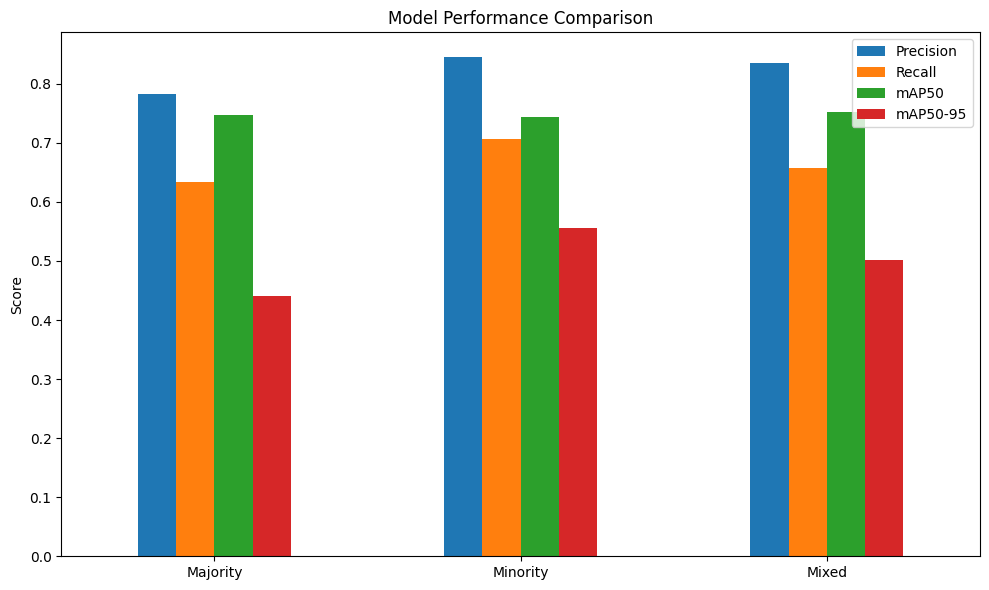

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

metrics = {}

for name, run_path in runs.items():
    csv_path = os.path.join(run_path, "results.csv")
    df = pd.read_csv(csv_path)
    last = df.iloc[-1]  # last epoch

    metrics[name] = {
        "Precision": last.get("metrics/precision(B)", None),
        "Recall": last.get("metrics/recall(B)", None),
        "mAP50": last.get("metrics/mAP50(B)", None),
        "mAP50-95": last.get("metrics/mAP50-95(B)", None),
    }

# Plot
df_plot = pd.DataFrame(metrics).T

df_plot.plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=300)
plt.show()

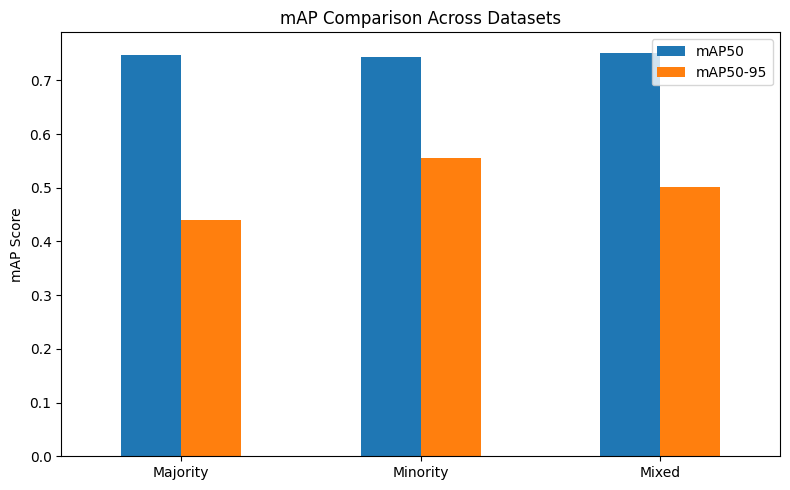

In [9]:
df_plot[["mAP50","mAP50-95"]].plot(kind='bar', figsize=(8,5))
plt.title("mAP Comparison Across Datasets")
plt.ylabel("mAP Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("map_comparison.png", dpi=300)
plt.show()

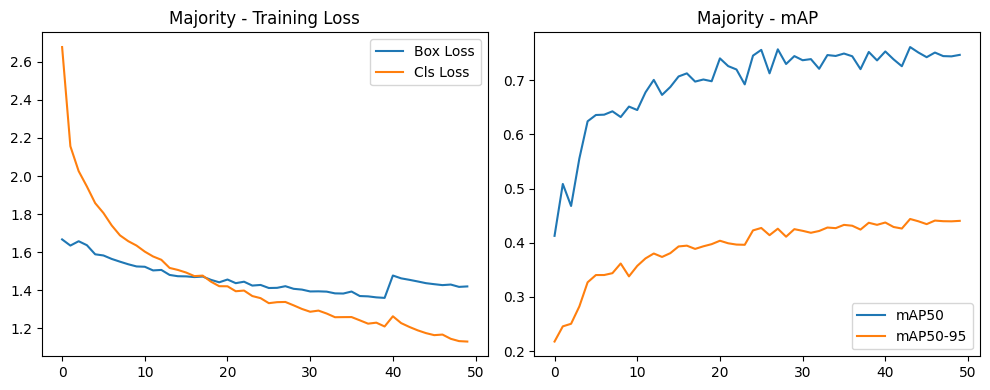

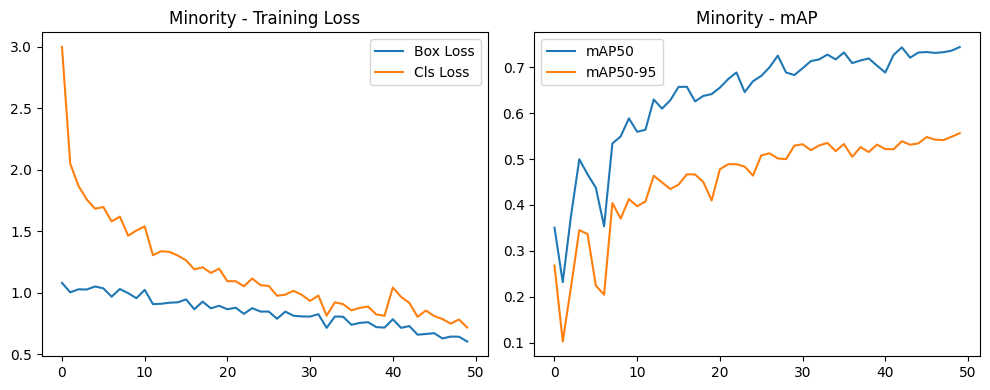

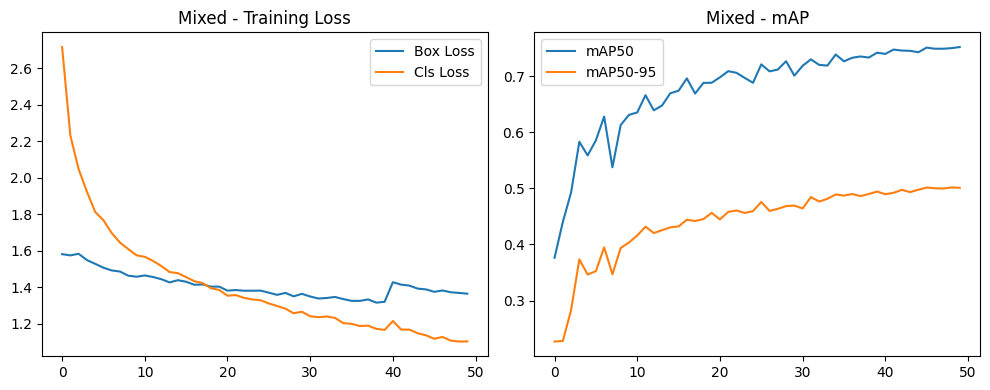

In [10]:
for name, run_path in runs.items():
    df = pd.read_csv(os.path.join(run_path, "results.csv"))

    plt.figure(figsize=(10,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(df['train/box_loss'], label='Box Loss')
    plt.plot(df['train/cls_loss'], label='Cls Loss')
    plt.title(f"{name} - Training Loss")
    plt.legend()

    # mAP
    plt.subplot(1,2,2)
    plt.plot(df['metrics/mAP50(B)'], label='mAP50')
    plt.plot(df['metrics/mAP50-95(B)'], label='mAP50-95')
    plt.title(f"{name} - mAP")
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"{name}_training_curves.png", dpi=300)
    plt.show()

In [17]:

for k,v in metrics.items():
    acc = (v["Precision"] + v["Recall"]) / 2
    print(f"{k} Accuracy (approx): {acc:.3f}")

Majority Accuracy (approx): 0.708
Minority Accuracy (approx): 0.775
Mixed Accuracy (approx): 0.746


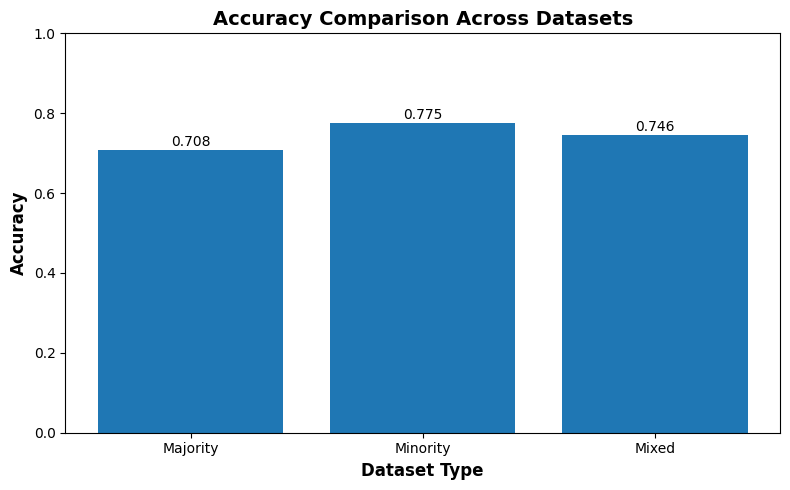

In [19]:
import matplotlib.pyplot as plt

# Calculate accuracy
accuracy_dict = {}

for k, v in metrics.items():
    acc = (v["Precision"] + v["Recall"]) / 2
    accuracy_dict[k] = acc

# Prepare data
names = list(accuracy_dict.keys())
values = list(accuracy_dict.values())

# Plot
plt.figure(figsize=(8,5))
plt.bar(names, values)

# Labels
plt.title("Accuracy Comparison Across Datasets", fontsize=14, fontweight='bold')
plt.xlabel("Dataset Type", fontsize=12, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12, fontweight='bold')

# Add value labels on top
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10)

plt.ylim(0, 1)
plt.tight_layout()

# Save
plt.savefig("accuracy_comparison.png", dpi=300)

plt.show()